# H3 — Diferencias climáticas entre ciudades

Comparamos el perfil climático de las 7 ciudades de Euskal Herria. La hipótesis es que costa e interior presentan patrones sistemáticamente distintos, y que estas diferencias pueden objetivarse mediante clustering.

## 1. Imports y carga de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.variables import CIUDADES, crear_dirs
from scripts.funciones_variables import cargar_datos
from scripts.analisis import estacionalidad, clustering_ciudades
from scripts.graficos import graficos_estacionalidad, graficos_clustering

crear_dirs()
cargar_datos()

📂 Cargando datos...
  ✅ bilbo: 31,412 filas
  ✅ donostia: 31,412 filas
  ✅ gasteiz: 31,412 filas
  ✅ iruna: 31,412 filas
  ✅ baiona: 31,412 filas
  ✅ arrasate: 31,412 filas
  ✅ maule: 31,412 filas



## 2. Comparativa de temperatura media anual

Serie anual de temperatura media para cada ciudad. Permite ver si las diferencias entre ciudades se mantienen constantes o si algunas se están calentando más rápido que otras.

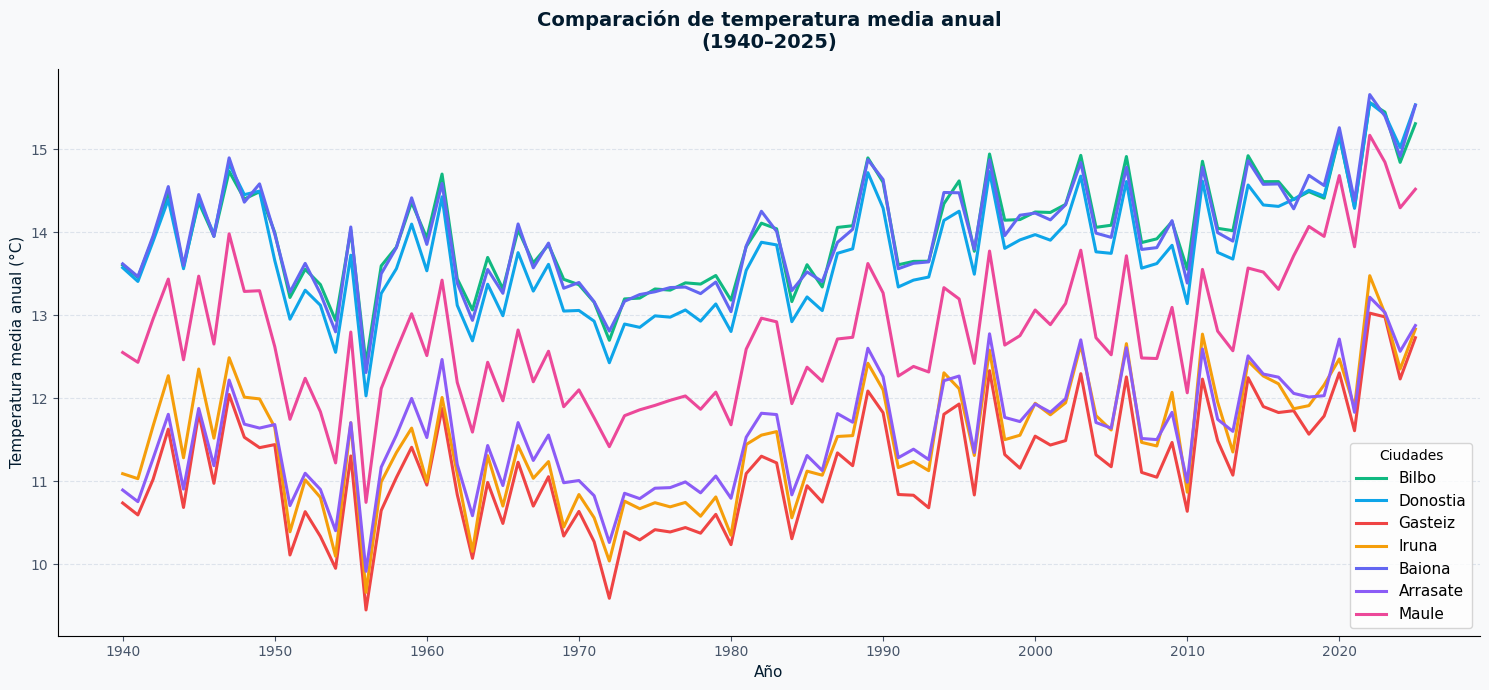

In [2]:
datos_estac = estacionalidad.calcular_todos()
graficos_estacionalidad.graficar_comparativa_ciudades(datos_estac['comp_temp'])

## 3. Comparativa de precipitación anual

Misma comparativa pero para precipitación. La diferencia entre ciudades costeras (lluviosas) e interior (más seco) debería ser muy marcada.

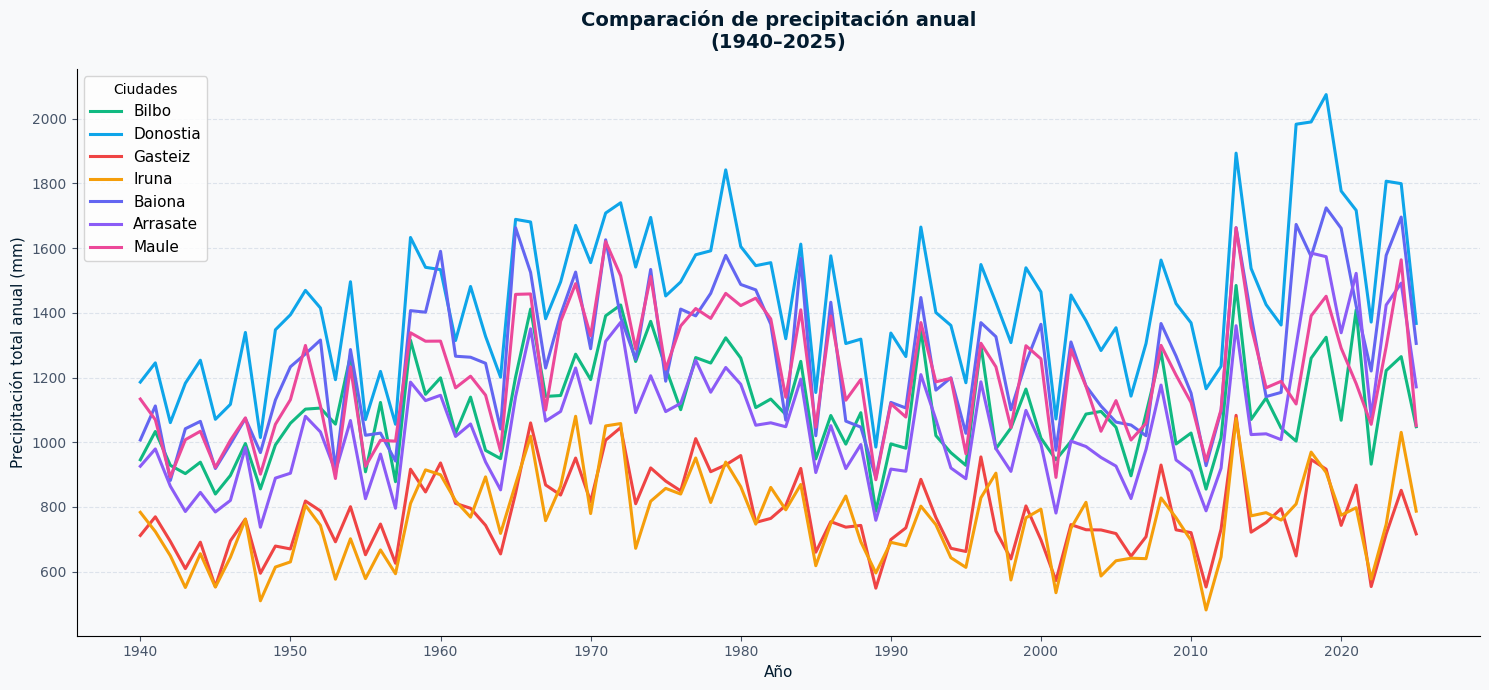

In [3]:
graficos_estacionalidad.graficar_comparativa_ciudades(datos_estac['comp_precip'])

## 4. Violinplot de distribución de temperatura diaria

Distribución completa de la temperatura media diaria por ciudad a lo largo de todo el período. Ciudades con violines más anchos tienen mayor variabilidad diaria.

/Users/nora/Documentos_Clase/BOOTCAMP/EDA/scripts/graficos/graficos_estacionalidad.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


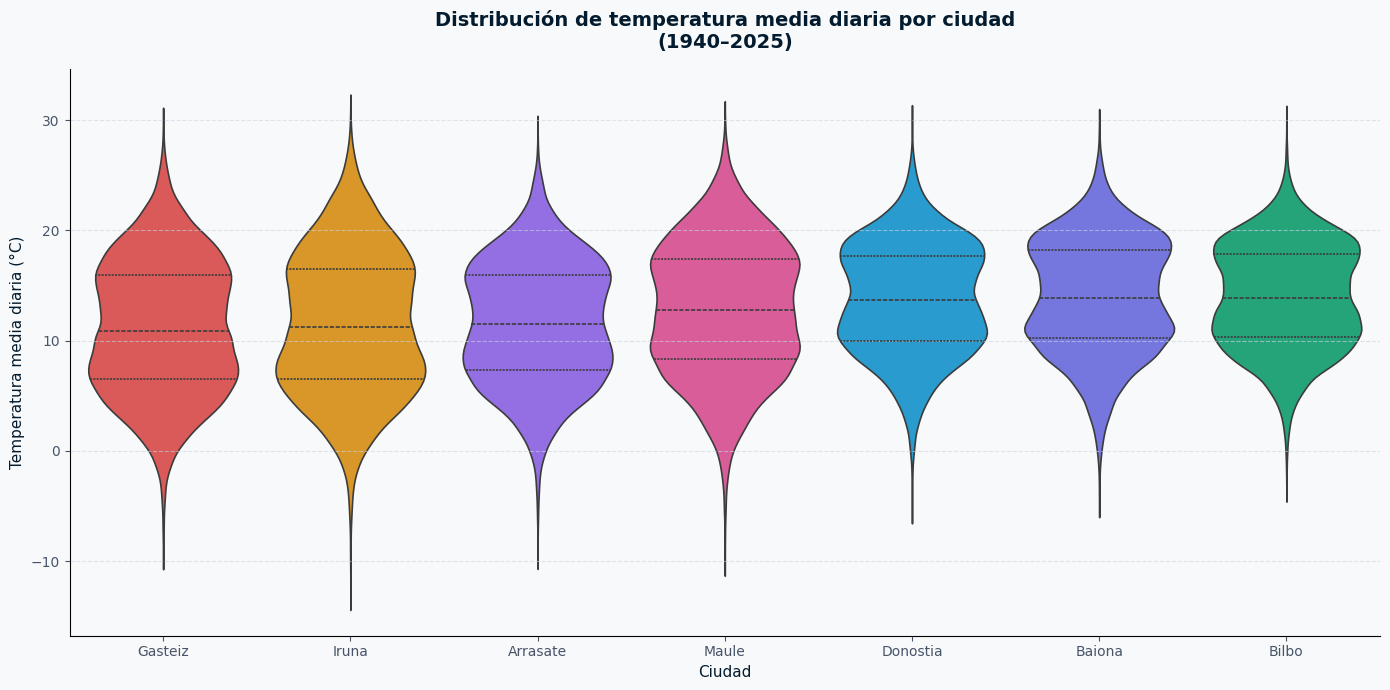

In [4]:
graficos_estacionalidad.graficar_violin_ciudades(CIUDADES)

## 5. Clustering jerárquico (dendrograma)

Agrupamos las ciudades por similitud de **perfil climático completo** (10 variables: temperaturas, precipitación, días extremos, racha seca, variabilidad). Ciudades unidas antes en el árbol = perfil más similar. Esperamos ver costa vs. interior como grupos diferenciados.

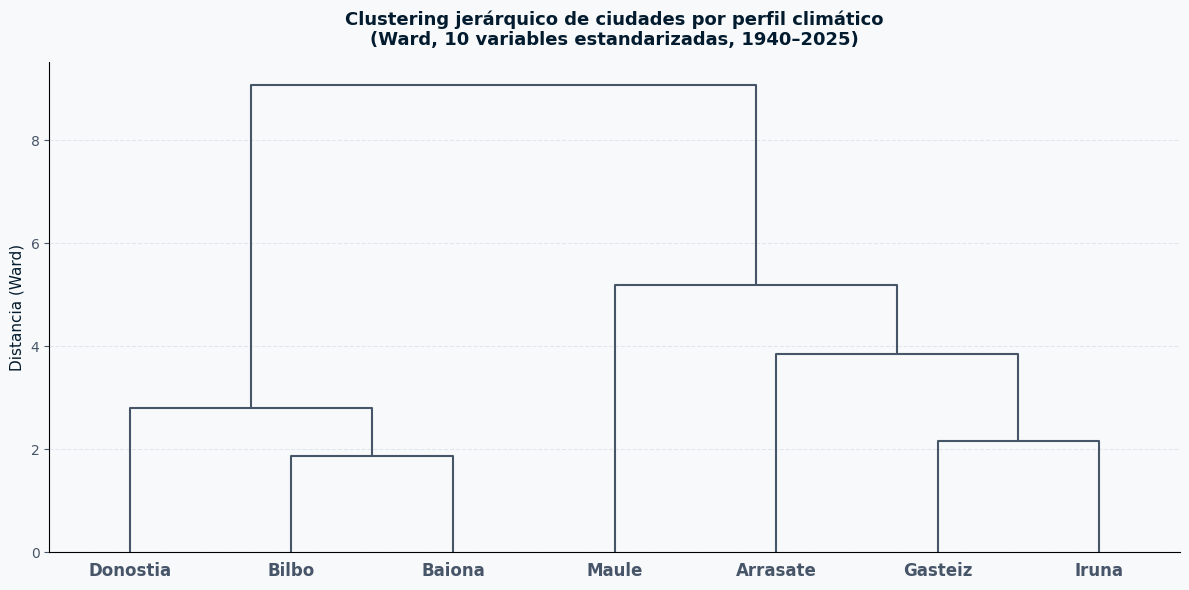

In [5]:
datos_cluster = clustering_ciudades.calcular_todos()
graficos_clustering.graficar_dendrograma(datos_cluster)

## 6. Heatmap del perfil climático (clustermap)

Mapa de calor de las variables estandarizadas por ciudad, con las ciudades y variables reordenadas por similitud (clustering jerárquico). Rojo = valor alto, azul = valor bajo respecto a la media de todas las ciudades.

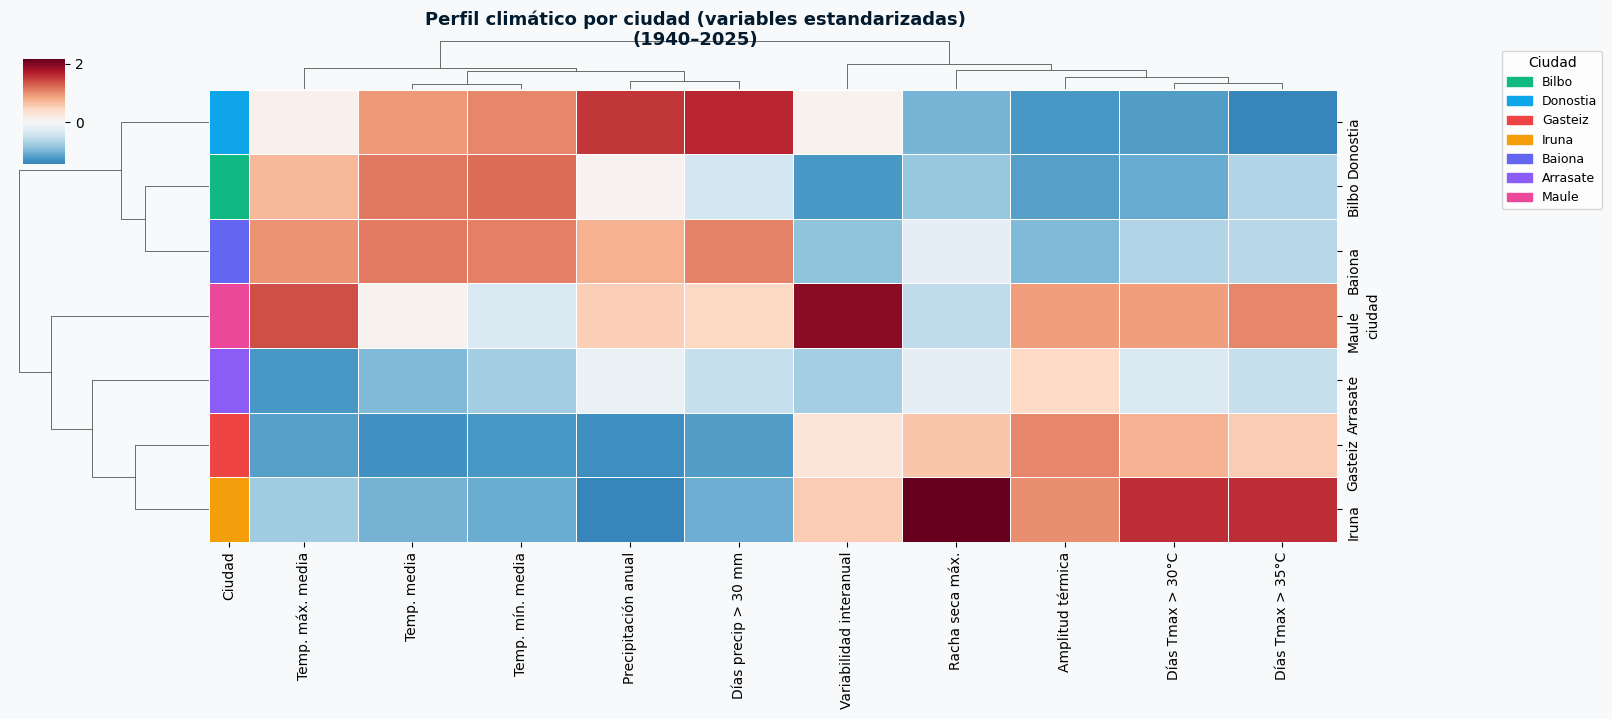

In [6]:
graficos_clustering.graficar_heatmap_perfil(datos_cluster)

## 7. Resumen del clustering

In [7]:
import pandas as pd

perfil = datos_cluster['perfil']
resumen = perfil[['ciudad', 'grupo', 'dist_mar', 'temp_media',
                   'precip_anual', 'dias_35', 'racha_seca']].copy()
resumen.columns = ['Ciudad', 'Grupo', 'Dist. mar (km)',
                   'Temp. media (°C)', 'Precip. anual (mm)',
                   'Días Tmax>35°C', 'Racha seca (días)']
resumen['Ciudad'] = resumen['Ciudad'].str.capitalize()
resumen = resumen.sort_values('Grupo')

for col in ['Temp. media (°C)', 'Precip. anual (mm)', 'Días Tmax>35°C', 'Racha seca (días)']:
    resumen[col] = resumen[col].round(1)

display(resumen.style.background_gradient(subset=['Temp. media (°C)'], cmap='RdYlBu_r')
               .background_gradient(subset=['Precip. anual (mm)'], cmap='Blues'))

,Ciudad,Grupo,Dist. mar (km),Temp. media (°C),Precip. anual (mm),Días Tmax>35°C,Racha seca (días)
0,Bilbo,1,11.100000,14.000000,1100.400000,0.500000,15.800000
1,Donostia,1,0.000000,13.800000,1437.400000,0.200000,15.200000
4,Baiona,1,1.500000,14.000000,1261.500000,0.500000,17.700000
2,Gasteiz,2,58.200000,11.200000,775.700000,0.900000,20.300000
3,Iruna,2,61.800000,11.500000,760.400000,1.300000,25.400000
5,Arrasate,2,33.200000,11.600000,1053.900000,0.500000,17.700000
6,Maule,3,25.200000,12.800000,1205.400000,1.100000,16.600000
